**Лабораторная работа №1**. Выявление характеристических признаков сигнала.

Цель работы - получить теоретические и практические навыки работы со звуковым сигналом.

1.1. Сгенерировать сэмпл белого или розового шума длительностью до 30 секунд (нечетная подгруппа - белый, чётная - розовый).\
1.2. Взять фильтр номер Х, где Х - номера подгруппы, и фильтр Y, где Y = остаток от деления (X+8) на 13.\
1.3. Определить и показать характеристики сигнала (как минимум, АЧХ) + спектрограмма по времени.\
1.4. Применить отдельно каждый фильтр.\
1.5. Показать спектрограмму по времени.

2.1. Взять 3 фрагмента сигнала: речь (монолог), чистая инструментальная музыка, интересный звуковой сэмпл до 30 секунд каждый.\
2.2. Определить и показать характеристики сигнала (как минимум, АЧХ) + спектрограмма по времени.\
2.3. Применить отдельно каждый фильтр.\
2.4. Показать спектрограмму по времени.\
2.5. Применить все фильтры последовательно.\
2.6. Показать спектрограмму по времени.

# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Часть 1

## Генерация розового шума

Розовый шум имеет спектральную плотность:

$$
P(f) ~ \frac{1}{f}
$$

То есть мощность уменьшается с ростом частоты.

In [2]:
fs = 44100        # частота дискретизации
duration = 10     # длительность сигнала
N = fs*duration

# генерация белого шума
white = np.random.randn(N)

# коэффициенты цифрового фильтра - аппроксимация фильтра 1/f, предложенная Paul Kellet
b = [0.049922035, -0.095993537, 0.050612699, -0.004408786]
a = [1, -2.494956002, 2.017265875, -0.522189400]

# генерация розового шума
pink = signal.lfilter(b, a, white)

## Характеристики сигнала

АЧХ (спектр)

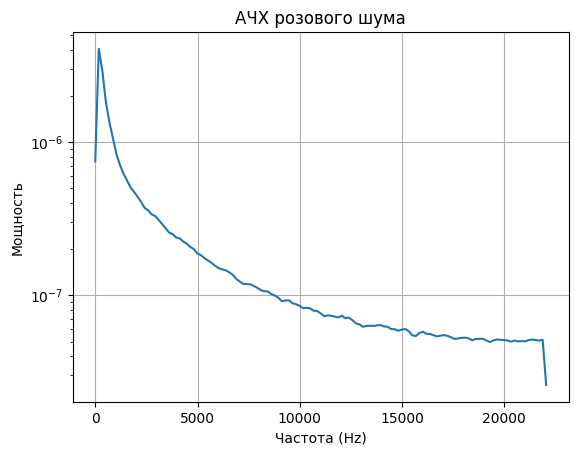

In [29]:
freqs, psd = signal.welch(pink, fs)

plt.figure()
plt.semilogy(freqs, psd)
plt.title("АЧХ розового шума")
plt.xlabel("Частота (Hz)")
plt.ylabel("Мощность")
plt.grid()
plt.show()

Спектрограмма по времени

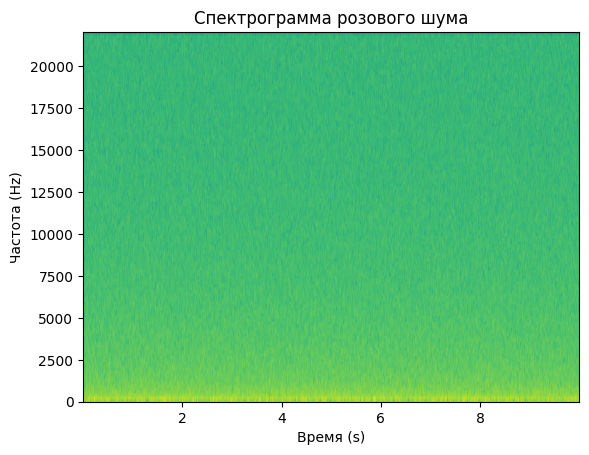

In [4]:
plt.figure()
plt.specgram(pink, Fs=fs)
plt.title("Спектрограмма розового шума")
plt.xlabel("Время (s)")
plt.ylabel("Частота (Hz)")
plt.show()

## Фильтр Бесселя

Фильтр Бесселя известен тем, что минимально искажает фазу сигнала.

In [16]:
def apply_filter(filter_fn, audio, order=4, cutoff=0.2, btype='low'):
    b, a = filter_fn(order, cutoff, btype=btype, analog=False)
    return signal.lfilter(b, a, audio)

In [17]:
#b_bessel, a_bessel = signal.bessel(4, 0.2, btype='low', analog=False)

#pink_bessel = signal.lfilter(b_bessel, a_bessel, pink)

pink_bessel = apply_filter(signal.bessel, pink)

Спектрограмма после фильтра Бесселя

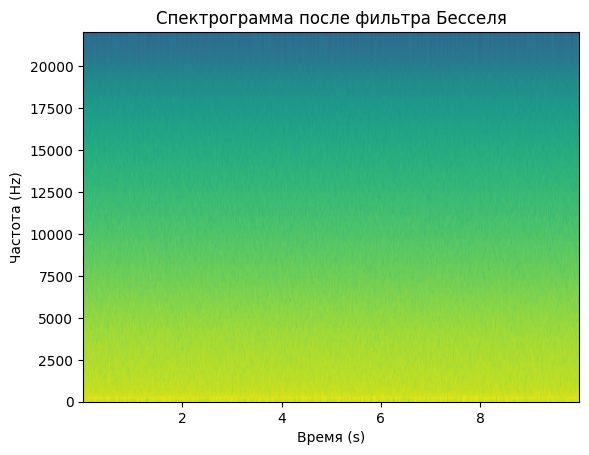

In [18]:
plt.figure()
plt.specgram(pink_bessel, Fs=fs)
plt.title("Спектрограмма после фильтра Бесселя")
plt.xlabel("Время (s)")
plt.ylabel("Частота (Hz)")
plt.show()

## Фильтр Баттерворта

Фильтр Баттерворта имеет максимально ровную АЧХ в полосе пропускания.

In [19]:
b_butter, a_butter = signal.butter(4, 0.2, btype='low')

pink_butter = pink_butter = apply_filter(signal.butter, pink)

Спектрограмма после фильтра Баттерворта

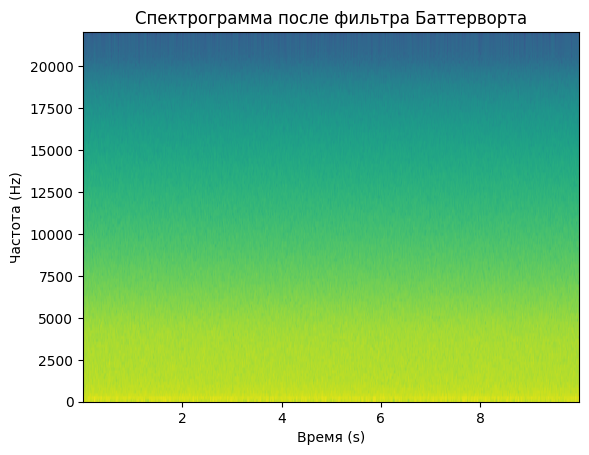

In [20]:
plt.figure()
plt.specgram(pink_butter, Fs=fs)
plt.title("Спектрограмма после фильтра Баттерворта")
plt.xlabel("Время (s)")
plt.ylabel("Частота (Hz)")
plt.show()

# Часть 2

In [56]:
import librosa
speech, sr = librosa.load("data/speech.wav", sr=None)
music, sr = librosa.load("data/instrumental.mp3", sr=None)
sample, sr = librosa.load("data/sample2.mp3", sr=None)

## Функции анализа сигнала

In [54]:
def plot_spectrum(audio, sr, title): #спектр (АЧХ)
    fft = np.fft.rfft(audio)
    freqs = np.fft.rfftfreq(len(audio), 1/sr)

    plt.figure()
    plt.plot(freqs, np.abs(fft))
    plt.title(f"Спектр: {title}")
    plt.xlabel("Частота (Hz)")
    plt.ylabel("Мощность")
    plt.show()

def plot_spectrogram(audio, sr, title): #Спектрограмма
    plt.figure()
    spec = librosa.stft(audio)
    spec_db = librosa.amplitude_to_db(np.abs(spec))

    librosa.display.specshow(spec_db, sr=sr, x_axis="time", y_axis="hz")
    plt.colorbar()
    plt.title(f"Спектрограмма: {title}")
    plt.show()

## Анализ оригинальных сигналов

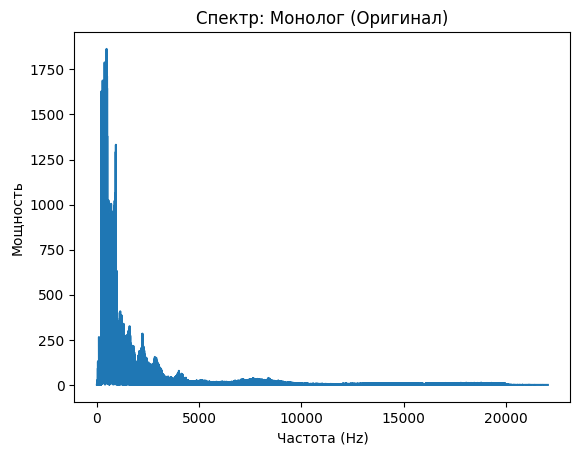

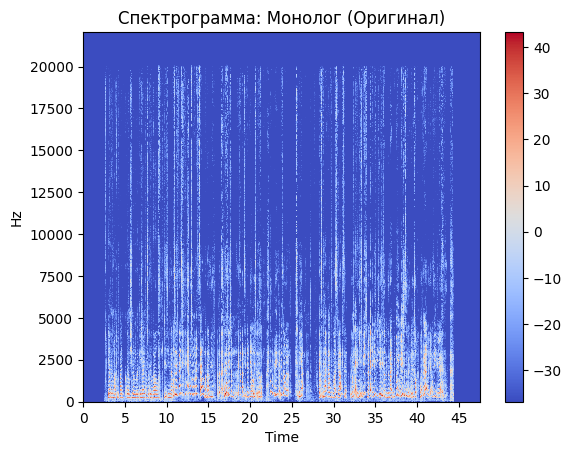

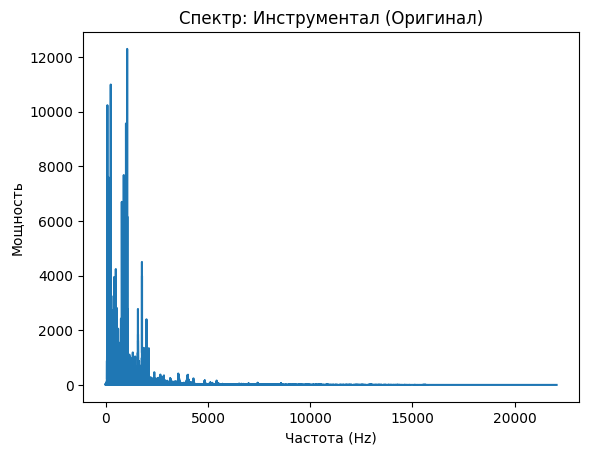

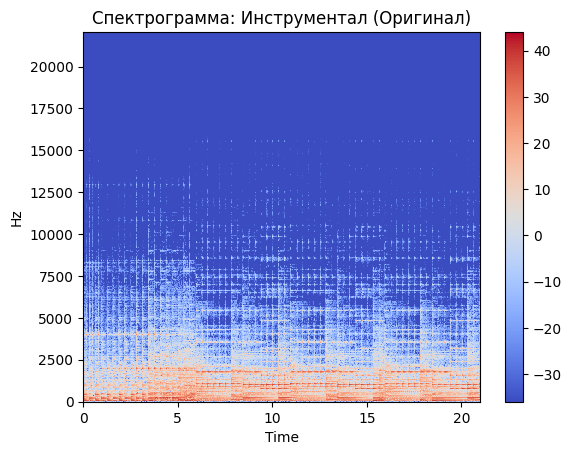

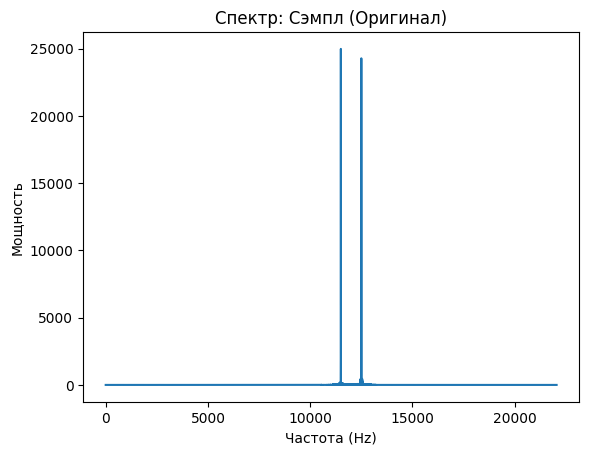

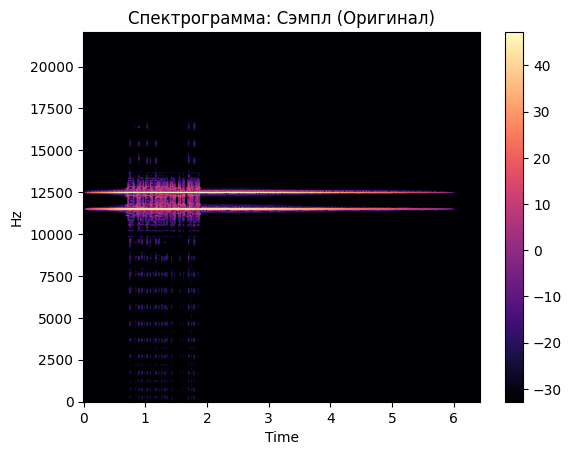

In [57]:
plot_spectrum(speech, sr, "Монолог (Оригинал)")
plot_spectrogram(speech, sr, "Монолог (Оригинал)")

plot_spectrum(music, sr, "Инструментал (Оригинал)")
plot_spectrogram(music, sr, "Инструментал (Оригинал)")

plot_spectrum(sample, sr, "Сэмпл (Оригинал)")
plot_spectrogram(sample, sr, "Сэмпл (Оригинал)")

## Фильтр Бесселя

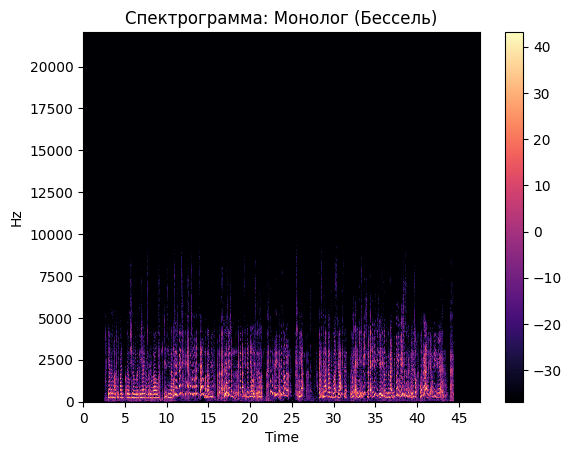

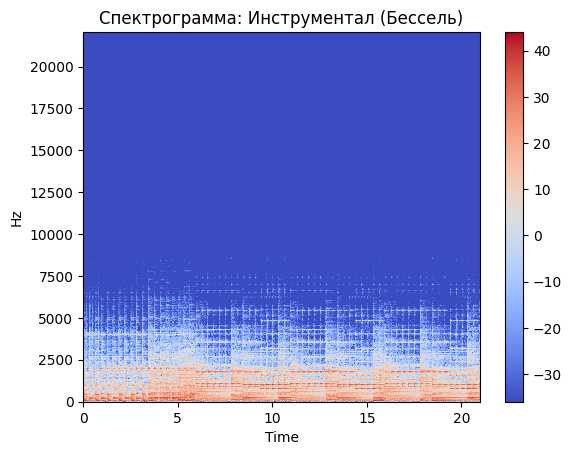

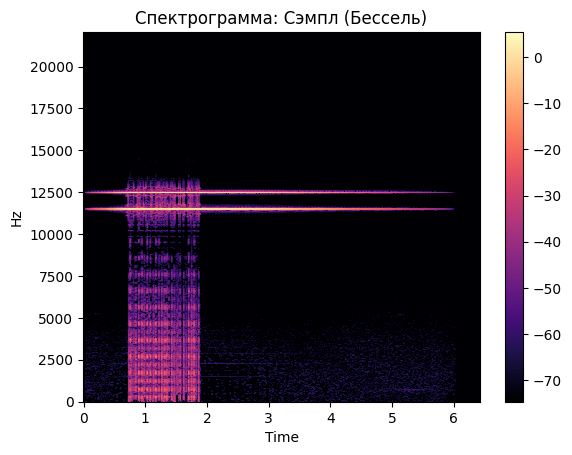

In [58]:
speech_bessel = apply_filter(signal.bessel, speech)
music_bessel = apply_filter(signal.bessel, music)
sample_bessel = apply_filter(signal.bessel, sample)
plot_spectrogram(speech_bessel, sr, "Монолог (Бессель)")
plot_spectrogram(music_bessel, sr, "Инструментал (Бессель)")
plot_spectrogram(sample_bessel, sr, "Сэмпл (Бессель)")

## Фильтр Баттерворта

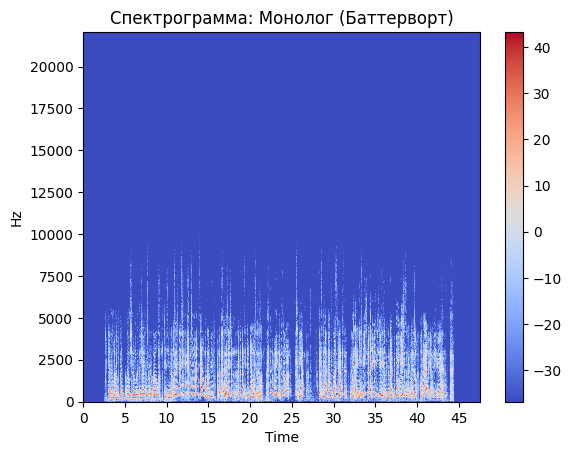

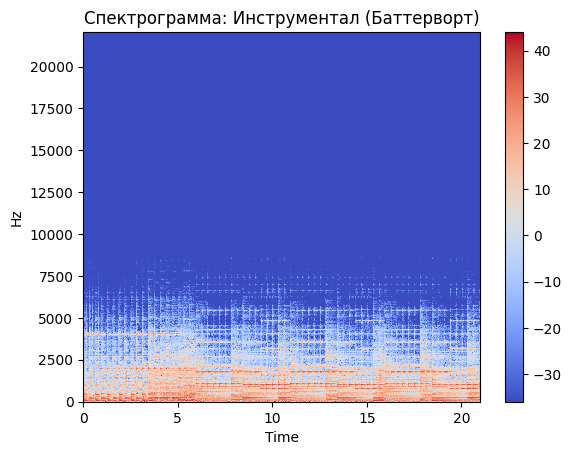

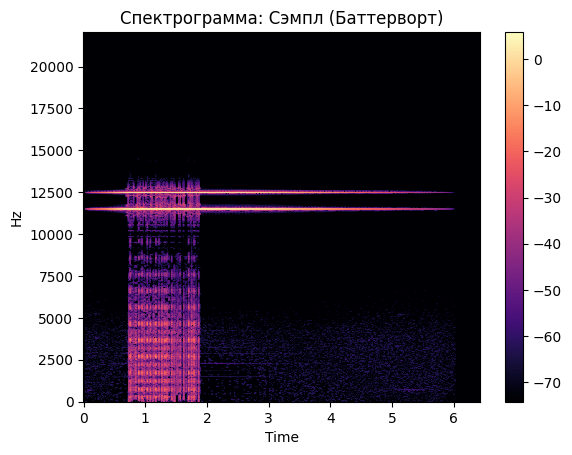

In [59]:
speech_butter = apply_filter(signal.butter, speech)
music_butter = apply_filter(signal.butter, music)
sample_butter = apply_filter(signal.butter, sample)
plot_spectrogram(speech_butter, sr, "Монолог (Баттерворт)")
plot_spectrogram(music_butter, sr, "Инструментал (Баттерворт)")
plot_spectrogram(sample_butter, sr, "Сэмпл (Баттерворт)")

## Цепочка Бессель + Баттерворт

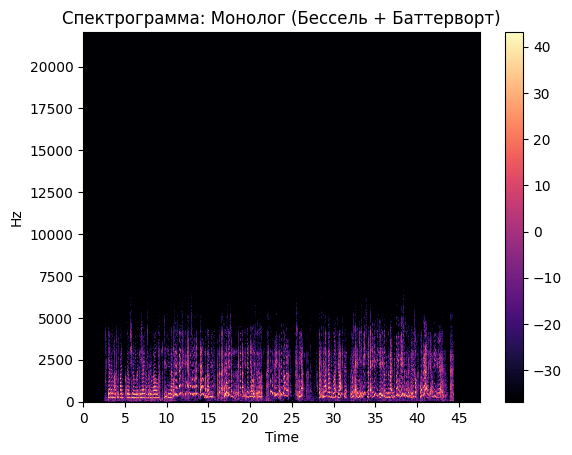

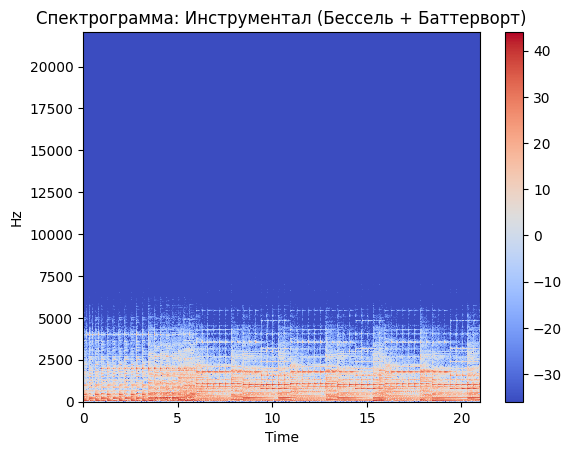

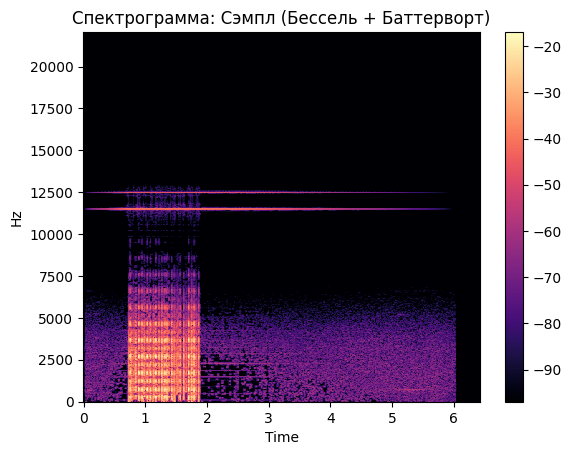

In [60]:
speech_chain = apply_filter(signal.butter, speech_bessel)
music_chain = apply_filter(signal.butter, music_bessel)
sample_chain = apply_filter(signal.butter, sample_bessel)
plot_spectrogram(speech_chain, sr, "Монолог (Бессель + Баттерворт)")
plot_spectrogram(music_chain, sr, "Инструментал (Бессель + Баттерворт)")
plot_spectrogram(sample_chain, sr, "Сэмпл (Бессель + Баттерворт)")